<a href="https://colab.research.google.com/github/dripston/empty-repo/blob/master/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [16]:
housing=fetch_california_housing()

df=pd.DataFrame(housing.data,columns=housing.feature_names)
df['Price'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
print(df.isnull().sum())
print(df.describe())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704

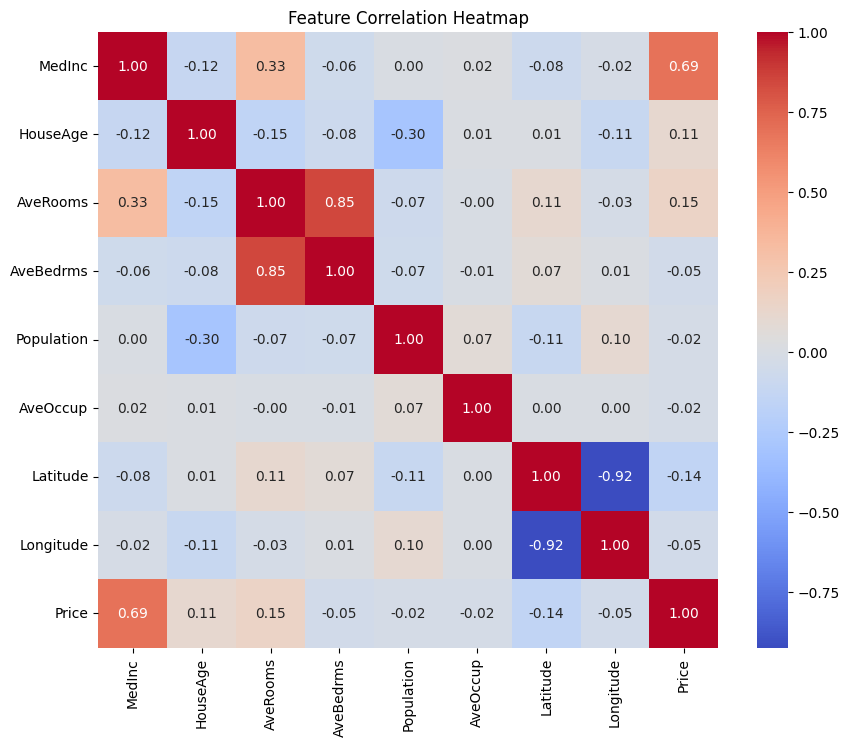

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [20]:
X=df.drop('Price',axis=1).values
Y=df['Price'].values

print(X.shape)
print(Y.shape)

(20640, 8)
(20640,)


In [23]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [24]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
model=keras.Sequential([
    layers.Dense(1, input_shape=(X_train.shape[1],))
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
history=model.fit(
    X_train,Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.8291 - mae: 1.9448 - val_loss: 4.7511 - val_mae: 1.6740
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.2289 - mae: 1.4827 - val_loss: 2.9013 - val_mae: 1.2874
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7492 - mae: 1.1337 - val_loss: 1.8229 - val_mae: 0.9821
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8905 - mae: 0.8725 - val_loss: 1.2091 - val_mae: 0.7631
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4099 - mae: 0.7031 - val_loss: 0.8905 - val_mae: 0.6427
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1555 - mae: 0.6186 - val_loss: 0.7389 - val_mae: 0.5923
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0209 - mae: 0.5876 - val_loss: 0.6706 - val_mae: 0.5790
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9453 - mae: 0.5756 - val_loss: 0.6377 - val_mae: 0.5767
Epoch 9/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

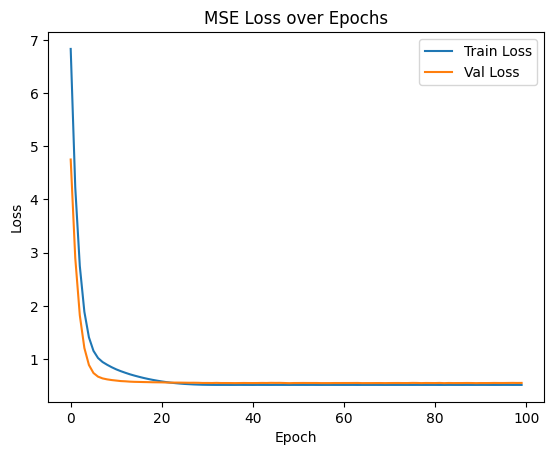

In [30]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("MSE Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5630 - mae: 0.5316
Test MSE: 0.5630
Test MAE: 0.5316
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


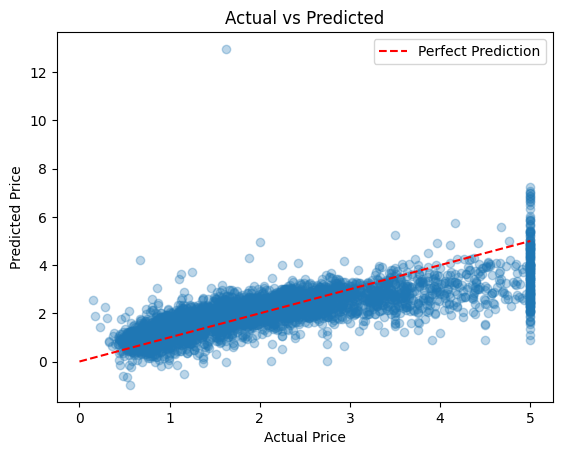

In [32]:
test_loss, test_mae = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")  # e.g. 0.53 means ~$53,000 avg error

y_pred = model.predict(X_test).flatten()

plt.scatter(Y_test, y_pred, alpha=0.3)
plt.plot([0, 5], [0, 5], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [33]:
weights, bias = model.layers[0].get_weights()

for feature, weight in zip(housing.feature_names, weights.flatten()):
    print(f"{feature:12s} → weight: {weight:.4f}")

print(f"\nBias: {bias[0]:.4f}")

MedInc       → weight: 0.8443
HouseAge     → weight: 0.1252
AveRooms     → weight: -0.2785
AveBedrms    → weight: 0.3474
Population   → weight: -0.0031
AveOccup     → weight: -0.0396
Latitude     → weight: -0.8917
Longitude    → weight: -0.8749

Bias: 2.0655
